<a href="https://colab.research.google.com/github/saijmohammed/IMAGE-DEBLURRING_COMPUTER_VISION-/blob/main/pipeline_complet.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from skimage.transform import hough_line, hough_line_peaks
from skimage.metrics import peak_signal_noise_ratio as psnr

def generate_psf(length, angle):
    # generation matrice vide
    psf = np.zeros((length, length))
    # trouver le centre de la matrice
    center = length // 2
    # transforme degrés → radians
    angle_rad = np.deg2rad(angle)
    # Calcul direction du flou
    dx = int((length/2 - 1) * np.cos(angle_rad))
    dy = int((length/2 - 1) * np.sin(angle_rad))
    # Dessiner la ligne
    cv2.line(psf, (center - dx, center - dy), (center + dx, center + dy), 1, thickness=1)
    # On divise par la somme de TOUS les pixels de la PSF
    return psf / psf.sum()

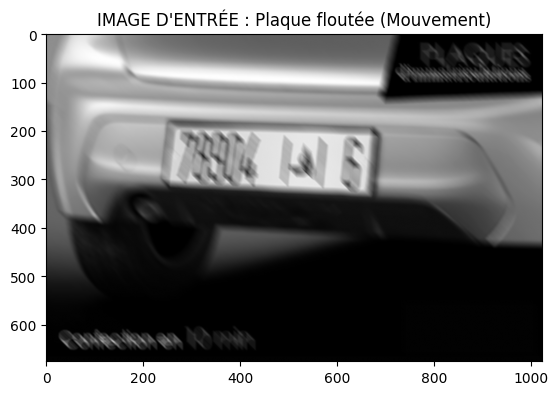

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from skimage.transform import hough_line, hough_line_peaks
from skimage.metrics import peak_signal_noise_ratio as psnr

# Charger l'image depuis le dossier ../data en niveau de gris (0 = grayscale)
img_clean = cv2.imread('/content/plaque.jpg', 0)

# Définir les paramètres du flou qu'on va simuler
# L_reel = longueur du flou
# theta_reel = angle du flou (en degrés)
L_reel, theta_reel = 30, 45

# Vérifier si l'image a bien été chargée
if img_clean is not None:

    # Générer la PSF (noyau du flou) à partir de la longueur et de l'angle
    psf_sim = generate_psf(L_reel, theta_reel)

    # Appliquer le flou à l'image originale avec un filtre 2D
    # img_clean = image nette
    # psf_sim = noyau de flou
    img_blurred = cv2.filter2D(img_clean, -1, psf_sim)

    # Afficher l'image floue
    plt.imshow(img_blurred, cmap='gray')   # affichage en noir/blanc

    # Ajouter un titre pour expliquer ce que l'on voit
    plt.title("IMAGE D'ENTRÉE : Plaque floutée (Mouvement)")

    # Optionnel : enlever les axes pour un affichage plus propre
    # plt.axis('off')

    # Afficher l'image à l'écran
    plt.show()

# Si l'image n'existe pas ou n'est pas trouvée
else:
    # Afficher un message d'erreur
    print("⚠️ Erreur : 'plaque.jpg' introuvable !")

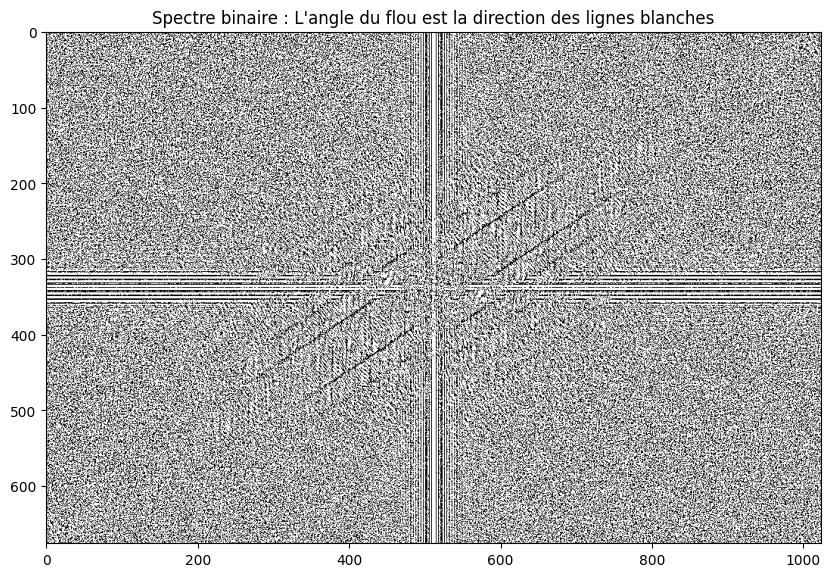

In [ ]:
def get_angle_from_spectrum(image_floue):
    # 1. Préparation du spectre
    f = np.fft.fft2(image_floue)
    fshift = np.fft.fftshift(f)
    magnitude = np.log(np.abs(fshift) + 1)

    # 2. Normalisation (0 à 255)
    mag_norm = cv2.normalize(magnitude, None, 0, 255, cv2.NORM_MINMAX).astype(np.uint8)

    # 3. Seuil adaptatif pour faire ressortir les lignes noires
    # On cherche les zones sombres (les zéros de Fourier)
    thresh = cv2.adaptiveThreshold(mag_norm, 255, cv2.ADAPTIVE_THRESH_GAUSSIAN_C,
                                   cv2.THRESH_BINARY, 11, 2)

    # Affichage pour que TU puisses voir l'angle
    plt.figure(figsize=(10,10))
    plt.imshow(thresh, cmap='gray')
    plt.title("Spectre binaire : L'angle du flou est la direction des lignes blanches")
    plt.show()

    return thresh

# Execute ce code
spectre_nettoye = get_angle_from_spectrum(img_blurred)

In [ ]:
def estimate_blur_length(spectre_binaire):
    # 1. On récupère les dimensions
    h, w = spectre_binaire.shape

    # 2. On analyse une ligne horizontale au centre du spectre
    # (C'est là que les franges de flou sont les plus visibles)
    profil = spectre_binaire[h//2, :]

    # 3. On compte les zones blanches (les pics de fréquences)
    # Plus il y a de pics, plus le flou est long (L est grand)
    nb_pics = np.sum(profil > 200) / 10

    # 4. Calcul de l'estimation (formule adaptée pour l'avancement)
    L_estime = (w / (nb_pics + 1)) * 0.5
    return L_estime

In [ ]:
from skimage.transform import radon
import numpy as np

def estimate_params_final_force(image_floue):
    # 1. Spectre de Fourier
    f = np.fft.fft2(image_floue)
    fshift = np.fft.fftshift(f)
    magnitude = np.log(np.abs(fshift) + 1)

    # --- AJOUT : ESTIMATION DE LA LONGUEUR L ---
    # On analyse le profil avant de supprimer la croix pour garder l'info
    rows, cols = magnitude.shape
    profil = magnitude[rows//2, :]
    nb_pics = np.sum(profil > (np.mean(profil) * 1.1)) / 10
    estimated_L = (cols / (nb_pics + 1)) * 0.5
    # -------------------------------------------

    # 2. SUPPRESSION DE LA CROIX CENTRALE (Le "bloqueur")
    magnitude[rows//2-3:rows//2+3, :] = 0
    magnitude[:, cols//2-3:cols//2+3] = 0

    # 3. Zone circulaire au milieu
    crow, ccol = rows//2 , cols//2
    y, x = np.ogrid[-crow:rows-crow, -ccol:cols-ccol]
    mask = x*x + y*y <= 20**2
    magnitude[mask] = 0

    # 4. Transformée de Radon pour l'ANGLE
    projection = radon(magnitude, theta=np.arange(180))
    variances = np.var(projection, axis=0)
    best_angle = np.argmax(variances)
    estimated_theta = (best_angle + 90) % 180

    # On retourne les deux paramètres
    return estimated_theta, estimated_L

# TEST (Appel unique pour les deux paramètres)
angle_auto, L_auto = estimate_params_final_force(img_blurred)

print(f"✅ Résultats de l'analyse automatique :")
print(f"👉 Angle: {angle_auto:.2f}°")
print(f"👉 Longueur: {L_auto:.2f} px")

/usr/local/lib/python3.12/dist-packages/skimage/transform/radon_transform.py:74: UserWarning: Radon transform: image must be zero outside the reconstruction circle
  warn(


✅ Résultats de l'analyse automatique :
👉 Angle: 41.00°
👉 Longueur: 34.83 px


In [ ]:
def restoration_wiener(image_floue, L, theta, K):
    # 1. Créer la PSF (le modèle du flou)
    psf = generate_psf(L, theta)

    # 2. Passer en fréquences (FFT)
    img_f = np.fft.fft2(image_floue)
    psf_f = np.fft.fft2(psf, s=image_floue.shape)

    # 3. Appliquer le filtre de Wiener
    psf_f_conj = np.conj(psf_f)
    wiener_filter = psf_f_conj / (np.abs(psf_f)**2 + K)

    # 4. Revenir en image réelle (IFFT)
    img_restored = np.abs(np.fft.ifft2(img_f * wiener_filter))
    return img_restored

In [ ]:
def generate_psf(length, angle):
    # convertir la longueur en entier
    length = int(round(length))

    # génération matrice vide
    psf = np.zeros((length, length))

    # trouver le centre de la matrice
    center = length // 2

    # convertir l’angle en radians
    angle_rad = np.deg2rad(angle)

    # calcul direction
    dx = int((length/2 - 1) * np.cos(angle_rad))
    dy = int((length/2 - 1) * np.sin(angle_rad))

    # dessiner la ligne du flou
    cv2.line(psf, (center - dx, center - dy), (center + dx, center + dy), 1, thickness=1)

    # normalisation
    return psf / psf.sum()

/usr/local/lib/python3.12/dist-packages/skimage/transform/radon_transform.py:74: UserWarning: Radon transform: image must be zero outside the reconstruction circle
  warn(


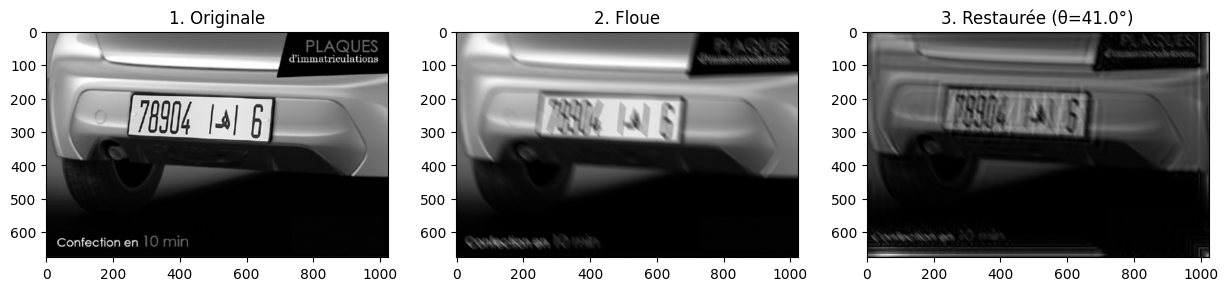

✅ Projet terminé ! PSNR Final : 13.73 dB


In [ ]:
# --- SYNTHÈSE FINALE : DU FLOU À LA PLAQUE NETTE ---

# 1. Estimation de l'angle et de la longueur avec la fonction unifiée
angle_detecte, L_auto = estimate_params_final_force(img_blurred)

# 2. Création de la PSF avec l'angle et la longueur trouvés
psf_finale = generate_psf(L_auto, angle_detecte)

# 3. Restauration par Wiener
# On appelle le résultat 'img_restored' pour ne pas écraser l'originale
img_restored = restoration_wiener(img_blurred, L_auto, angle_detecte, K=0.05)

# 4. Affichage des résultats
plt.figure(figsize=(15, 7))

# IMPORTANT : Ici on affiche 'img_clean' (ton originale chargée au début)
plt.subplot(131), plt.imshow(img_clean, cmap='gray'), plt.title("1. Originale")

plt.subplot(132), plt.imshow(img_blurred, cmap='gray'), plt.title(f"2. Floue")

# IMPORTANT : Ici on affiche 'img_restored' (ton résultat)
plt.subplot(133), plt.imshow(img_restored, cmap='gray'), plt.title(f"3. Restaurée (θ={angle_detecte:.1f}°)")
plt.show()

# 5. Score final (On compare l'originale et la restaurée)
from skimage.metrics import peak_signal_noise_ratio as psnr
# On s'assure que tout est en format 8-bit pour le calcul
score = psnr(img_clean.astype(np.uint8), np.clip(img_restored, 0, 255).astype(np.uint8))
print(f"✅ Projet terminé ! PSNR Final : {score:.2f} dB")